# Retail Demand Forecasting for Inventory Planning

## Business Problem

Retail inventory decisions depend on anticipating product demand early enough to support replenishment while limiting both stockouts and excess inventory.

This project investigates historical retail demand together with product, pricing, promotional, weather, seasonal, competitor and calendar information to support short-term demand forecasting.

## Project Objective

The objective is to develop a machine learning model that forecasts **daily product demand for each of the next seven days at store-product level**.

The forecasts are intended to support short-term inventory planning by estimating expected demand under the business conditions associated with each forecast date.

## Business Question

**Can historical demand and forecast-date business conditions be used to accurately forecast store-product demand over the next seven days?**

The analysis focuses on:

- variation in demand across products and categories;
- temporal and seasonal demand patterns;
- relationships between demand and pricing, promotions, weather and other external conditions; and
- historical demand signals that may improve future forecasts.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## 1. Data Loading and Initial Inspection

The retail demand dataset is loaded and reviewed to confirm its structure, data types, completeness, and level of granularity before analysis.

In [2]:
df = pd.read_csv('data/demand_forecasting.csv')

In [3]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [4]:
df.dtypes

Date                      str
Store ID                  str
Product ID                str
Category                  str
Region                    str
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition         str
Promotion               int64
Competitor Pricing    float64
Seasonality               str
Epidemic                int64
Demand                  int64
dtype: object

In [5]:
df['Date']= pd.to_datetime(df['Date'])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[us]
 1   Store ID            76000 non-null  str           
 2   Product ID          76000 non-null  str           
 3   Category            76000 non-null  str           
 4   Region              76000 non-null  str           
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  str           
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  str           
 14  E

In [7]:
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [10]:
df.groupby(['Date', 'Store ID', 'Product ID']).size().value_counts()

1    76000
Name: count, dtype: int64

### Data Quality Summary

The dataset contains one observation per store-product-date combination, with no duplicate records or missing values in the original data. This structure supports forecasting demand separately for each store-product series.

## 2. Target and Forecast-Time Feature Assessment

Before exploratory analysis, potential predictors are assessed based on both their relationship with demand and whether they would realistically be available when generating a future forecast.

In [11]:
df[['Demand', 'Units Sold', 'Units Ordered', 'Inventory Level']].corr()

,Demand,Units Sold,Units Ordered,Inventory Level
Demand,1.000000,0.833421,0.511963,0.126618
Units Sold,0.833421,1.000000,0.433943,0.234590
Units Ordered,0.511963,0.433943,1.000000,-0.034698
Inventory Level,0.126618,0.234590,-0.034698,1.000000


### Feature Selection Considerations

Demand is strongly correlated with Units Sold and moderately correlated with Units Ordered. However, same-period sales and ordering outcomes would not be available when forecasting future demand and are therefore excluded from the predictive feature set.

Historical demand is instead represented through lagged and rolling features.

Inventory Level is also excluded from the demand model and retained for the later inventory-planning layer, where forecast demand can be compared with available stock.

This separation ensures that the forecasting model uses information that could realistically be available at prediction time.

## 3. Initial Feature Preparation

Calendar and pricing features are derived from the existing data to support exploratory analysis and subsequent forecasting.

In [12]:
df["Year"] = df['Date'].dt.year
df["Month"] = df['Date'].dt.month
df["Day"] = df['Date'].dt.day
df["Weekday"] = df['Date'].dt.day_name()

In [13]:
df["Discounted_Price"] = df['Price'] * (1 - df['Discount'] / 100)

## 4. Exploratory Data Analysis

Exploratory analysis is used to examine the distribution of demand and identify patterns across products, pricing, promotions, weather, seasonal conditions, and time.

In [14]:
df.groupby('Category')['Demand'].agg(
    ["mean", "sum", "std", "count"]
).sort_values(
    by="sum",
    ascending=False
).reset_index()

,Category,mean,sum,std,count
0,Groceries,120.976447,3677684,48.362730,30400
1,Clothing,112.619737,1369456,41.022968,12160
2,Furniture,73.581140,1006590,32.336141,13680
3,Toys,92.606955,985338,46.170390,10640
4,Electronics,97.482018,889036,40.557859,9120


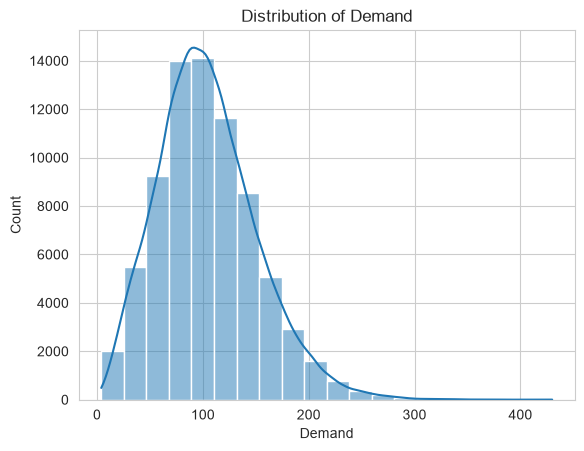

In [15]:
sns.histplot(df['Demand'], bins=20, kde=True)
plt.title('Distribution of Demand')
plt.show()

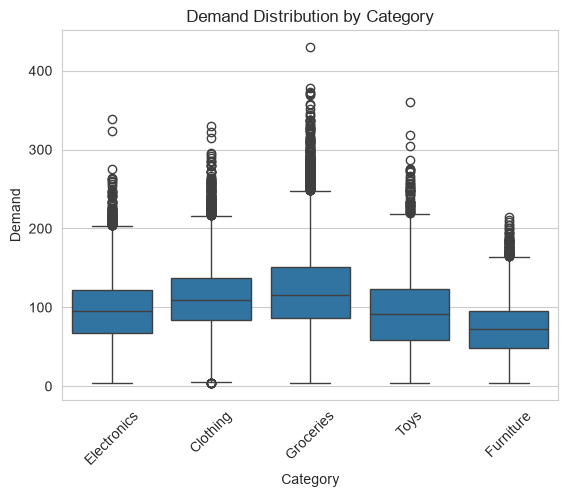

In [16]:
sns.boxplot(x='Category', y='Demand', data=df)
plt.xticks(rotation=45)
plt.title('Demand Distribution by Category')
plt.show()

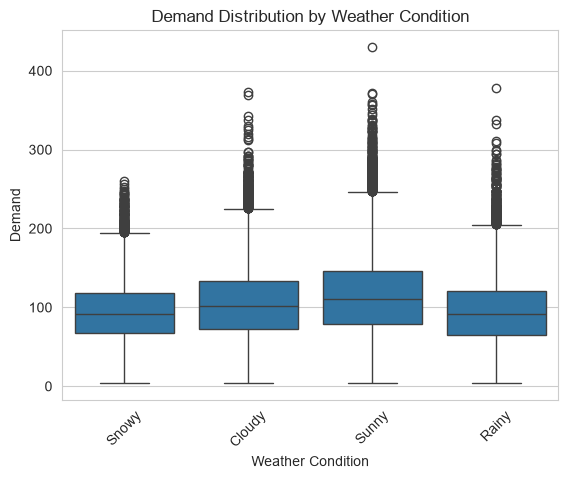

In [17]:
sns.boxplot(x='Weather Condition', y='Demand', data=df)
plt.xticks(rotation=45)
plt.title('Demand Distribution by Weather Condition')
plt.show()

In [18]:
monthly_demand = df.groupby('Month')['Demand'].mean()

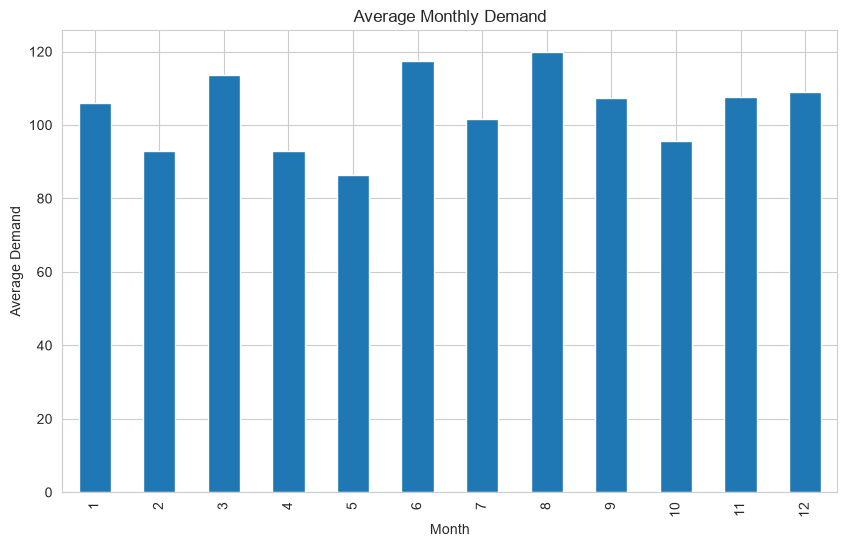

In [19]:
monthly_demand.plot(kind='bar', figsize=(10, 6))

plt.title('Average Monthly Demand')
plt.xlabel('Month')
plt.ylabel('Average Demand')

plt.show()

In [20]:
daily_demand=df.groupby('Date')['Demand'].sum()

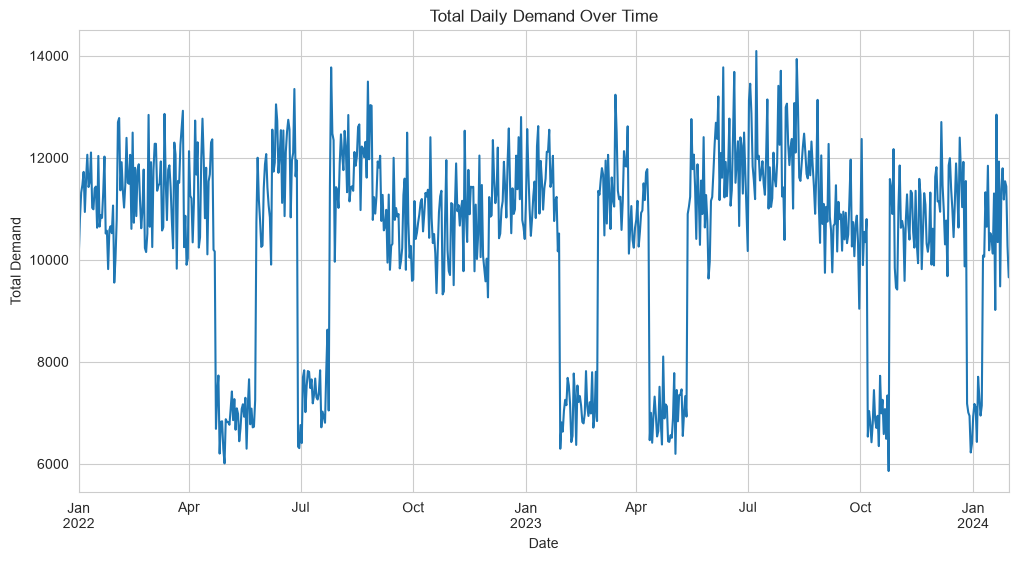

In [21]:
daily_demand.plot(figsize=(12, 6))

plt.title('Total Daily Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Total Demand')

plt.show()

### Demand Across Business and External Conditions

Demand is compared across promotional, pricing, seasonal, and external conditions to identify variables that may provide useful information for forecasting.

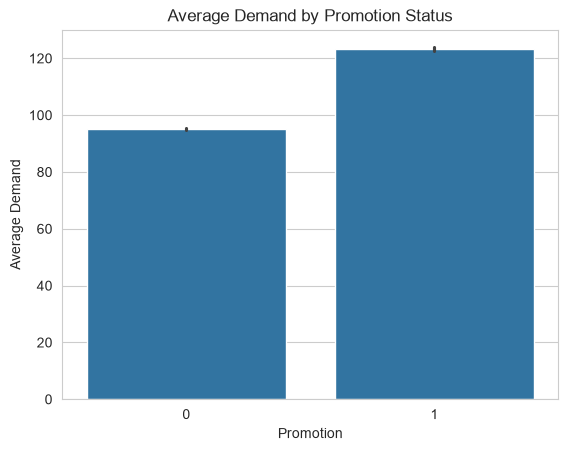

In [22]:
sns.barplot(x='Promotion', y='Demand', data=df)

plt.title('Average Demand by Promotion Status')
plt.xlabel('Promotion')
plt.ylabel('Average Demand')

plt.show()

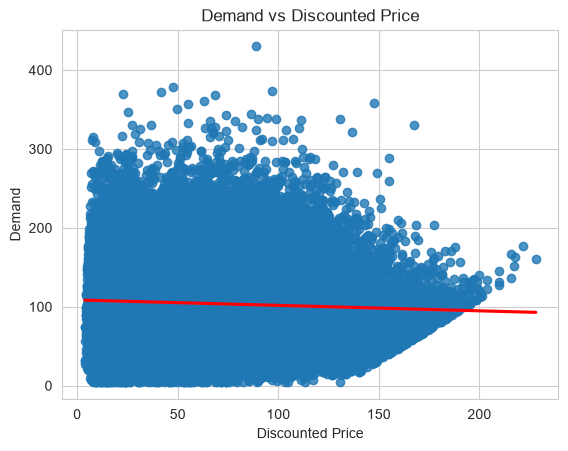

In [23]:
sns.regplot(
    x='Discounted_Price',
    y='Demand',
    data=df,
    line_kws={"color": "red"}
)

plt.title('Demand vs Discounted Price')
plt.xlabel('Discounted Price')
plt.ylabel('Demand')

plt.show()


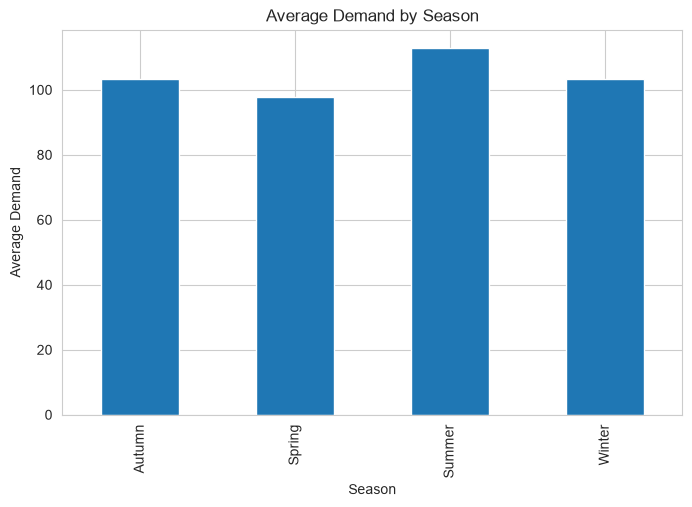

In [24]:
df.groupby('Seasonality')['Demand'].mean().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Demand by Season')
plt.xlabel('Season')
plt.ylabel('Average Demand')

plt.show()

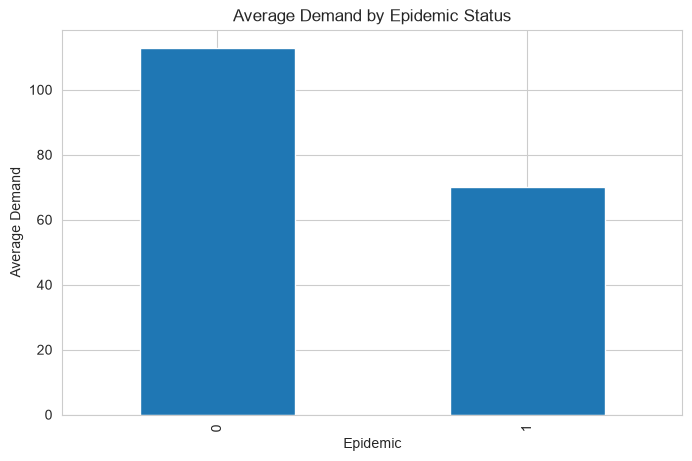

In [25]:
df.groupby('Epidemic')['Demand'].mean().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Demand by Epidemic Status')
plt.xlabel('Epidemic')
plt.ylabel('Average Demand')

plt.show()

In [26]:
sample_series = df[
    (df['Store ID'] == 'S001') &
    (df['Product ID'] == 'P0001')
].sort_values('Date')

sample_series[['Date', 'Demand']].head(10)

,Date,Demand
0,2022-01-01,115
100,2022-01-02,84
200,2022-01-03,132
300,2022-01-04,67
400,2022-01-05,110
500,2022-01-06,146
600,2022-01-07,87
700,2022-01-08,113
800,2022-01-09,87
900,2022-01-10,99


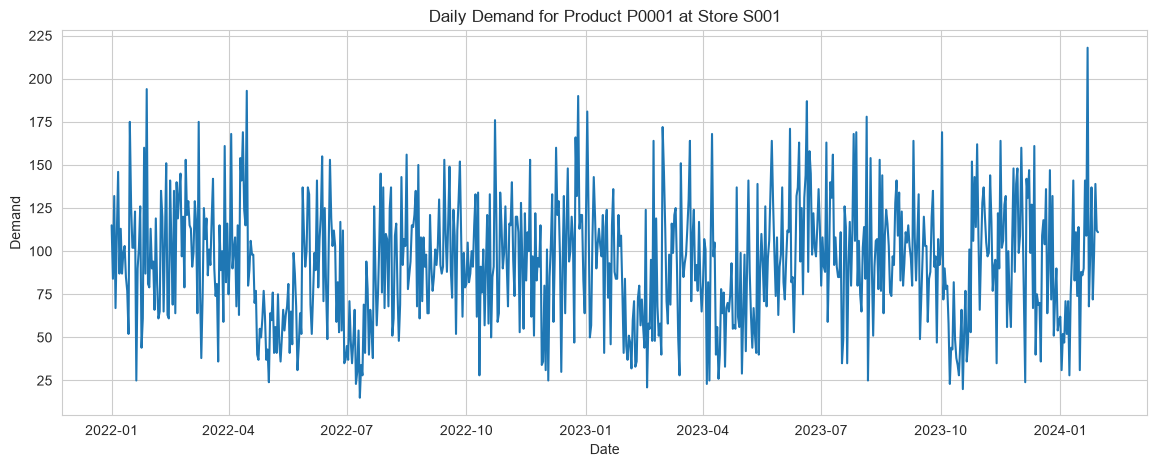

In [27]:
plt.figure(figsize=(14, 5))

plt.plot(
    sample_series['Date'],
    sample_series['Demand']
)

plt.title('Daily Demand for Product P0001 at Store S001')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.show()

In [28]:
sample_series['Demand_7Day_Avg'] = (
    sample_series['Demand']
    .rolling(window=7)
    .mean()
)

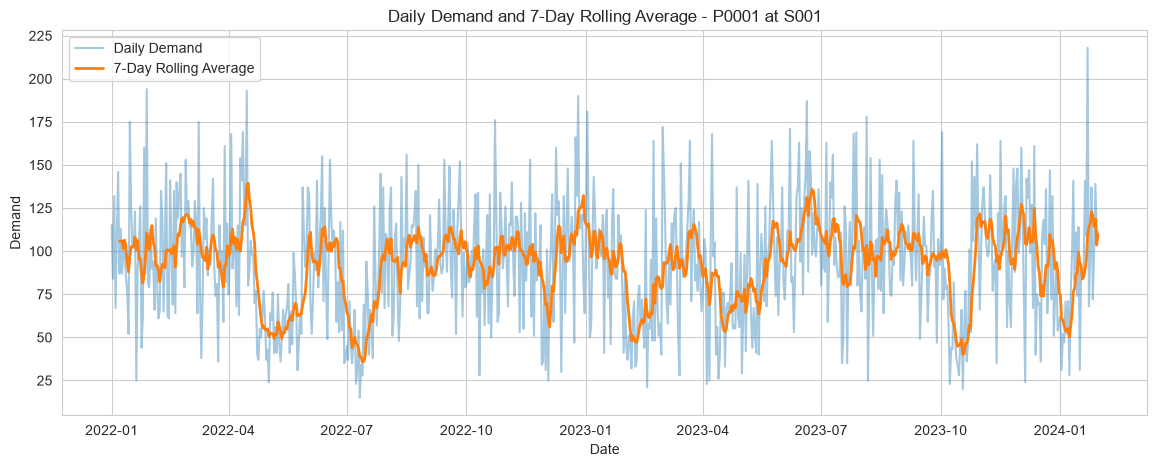

In [29]:
plt.figure(figsize=(14, 5))

plt.plot(
    sample_series['Date'],
    sample_series['Demand'],
    alpha=0.4,
    label='Daily Demand'
)

plt.plot(
    sample_series['Date'],
    sample_series['Demand_7Day_Avg'],
    linewidth=2,
    label='7-Day Rolling Average'
)

plt.title('Daily Demand and 7-Day Rolling Average - P0001 at S001')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.show()

### Short-Term Pattern Observation

Daily demand shows substantial short-term variation, while the 7-day rolling average provides a smoother representation of recent demand levels.

This supports the inclusion of lagged and rolling demand features in the forecasting model.

## 5. Product-Level Seasonal Patterns

Monthly demand is compared across products to assess whether seasonal patterns vary at product level.

In [30]:
product_monthly_pivot = df.pivot_table(
    index='Month',
    columns='Product ID',
    values='Demand',
    aggfunc='mean'
)

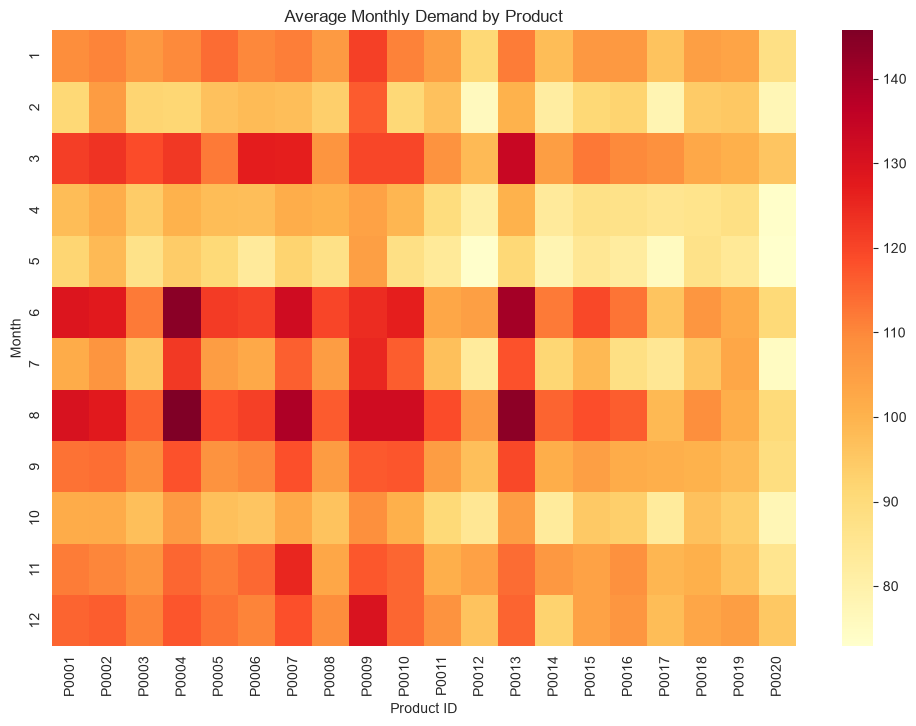

In [31]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    product_monthly_pivot,
    cmap='YlOrRd'
)

plt.title('Average Monthly Demand by Product')
plt.xlabel('Product ID')
plt.ylabel('Month')

plt.show()

Monthly demand patterns differ across products, supporting the inclusion of both product identity and calendar information in the forecasting model.

## 6. Forecasting Feature Engineering

Historical demand features are created separately for each store-product series.

Lagged demand captures recent historical observations, while the rolling feature summarises short-term demand levels. All modelling features are constructed using only demand observed before the forecast date to prevent target leakage.

In [32]:
df = df.sort_values(
    ['Store ID', 'Product ID', 'Date']
).reset_index(drop=True)

In [33]:
df['Demand_Lag_1'] = (
    df.groupby(['Store ID', 'Product ID'])['Demand']
      .shift(1)
)

In [34]:
df['Demand_Lag_7'] = (
    df.groupby(['Store ID', 'Product ID'])['Demand']
      .shift(7)
)

df['Demand_Lag_14'] = (
    df.groupby(['Store ID', 'Product ID'])['Demand']
      .shift(14)
)

In [35]:
df['Demand_Rolling_7'] = (
    df.groupby(['Store ID', 'Product ID'])['Demand']
      .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

In [36]:
df[
    ['Date', 'Store ID', 'Product ID', 'Demand',
     'Demand_Lag_1', 'Demand_Lag_7', 'Demand_Lag_14',
     'Demand_Rolling_7']
].head(21)

,Date,Store ID,Product ID,Demand,Demand_Lag_1,Demand_Lag_7,Demand_Lag_14,Demand_Rolling_7
0,2022-01-01,S001,P0001,115,NaN,NaN,NaN,NaN
1,2022-01-02,S001,P0001,84,115.0,NaN,NaN,NaN
2,2022-01-03,S001,P0001,132,84.0,NaN,NaN,NaN
3,2022-01-04,S001,P0001,67,132.0,NaN,NaN,NaN
4,2022-01-05,S001,P0001,110,67.0,NaN,NaN,NaN
5,2022-01-06,S001,P0001,146,110.0,NaN,NaN,NaN
6,2022-01-07,S001,P0001,87,146.0,NaN,NaN,NaN
7,2022-01-08,S001,P0001,113,87.0,115.0,NaN,105.857143
8,2022-01-09,S001,P0001,87,113.0,84.0,NaN,105.571429
9,2022-01-10,S001,P0001,99,87.0,132.0,NaN,106.000000


## 7. Export for Modelling

The cleaned dataset, calendar variables, pricing features, and historical demand features are exported for the machine learning stage.

The modelling notebook will use this dataset to construct forecast-date observations for horizons **1 through 7 days ahead**, align future-known business conditions with each forecast date, and predict `Target_Demand`.

In [37]:
df.to_csv(
    'data/preprocessed_demand_forecasting.csv',
    index=False
)

print("Preprocessed dataset exported successfully.")
print("Final shape:", df.shape)

Preprocessed dataset exported successfully.
Final shape: (76000, 25)
